# Supplementary Figure 3

Computational panels B–C.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)
S3_ROOT = ROOT / "src/manuscript_figures/figS3"

BLUE = "#2A78D6"
RED = "#D85A57"
GREEN = "#2F8F5B"
GRAY = "#A8A6A0"
INK = "#171717"
MUTED = "#66645F"
GRID = "#E6E6E2"
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "font.family": "DejaVu Sans", "svg.fonttype": "none"})

def style(ax, grid_axis=None):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(axis=grid_axis or "both", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

## Supplementary Figure 3B — program selectivity

Marker-set size and pathway count relative to perturbation DEG burden.

In [2]:
panel_b = S3_ROOT / "b"
report_summary = pd.read_csv(panel_b / "report_target_summary.tsv", sep="\t")
report_sizes = pd.read_csv(panel_b / "report_marker_gene_set_sizes.tsv", sep="\t").n_genes.to_numpy()
canonical_sizes = pd.read_csv(panel_b / "canonical_gene_set_sizes.tsv", sep="\t").n_genes.to_numpy()

assert len(report_summary) == 2_046
assert int(report_summary.n_programs.sum()) == 5_545
assert len(report_sizes) == 5_431 and np.median(report_sizes) == 5
assert len(canonical_sizes) == 8_866 and np.median(canonical_sizes) == 19

print(f"reports={len(report_summary):,}; programs={int(report_summary.n_programs.sum()):,}")
print(f"programs/report mean={report_summary.n_programs.mean():.2f}, median={report_summary.n_programs.median():.0f}")
print(f"report genes/program mean={report_sizes.mean():.2f}, median={np.median(report_sizes):.0f}")
print(f"canonical genes/pathway mean={canonical_sizes.mean():.2f}, median={np.median(canonical_sizes):.0f}")

reports=2,046; programs=5,545
programs/report mean=2.71, median=3
report genes/program mean=5.71, median=5
canonical genes/pathway mean=50.09, median=19


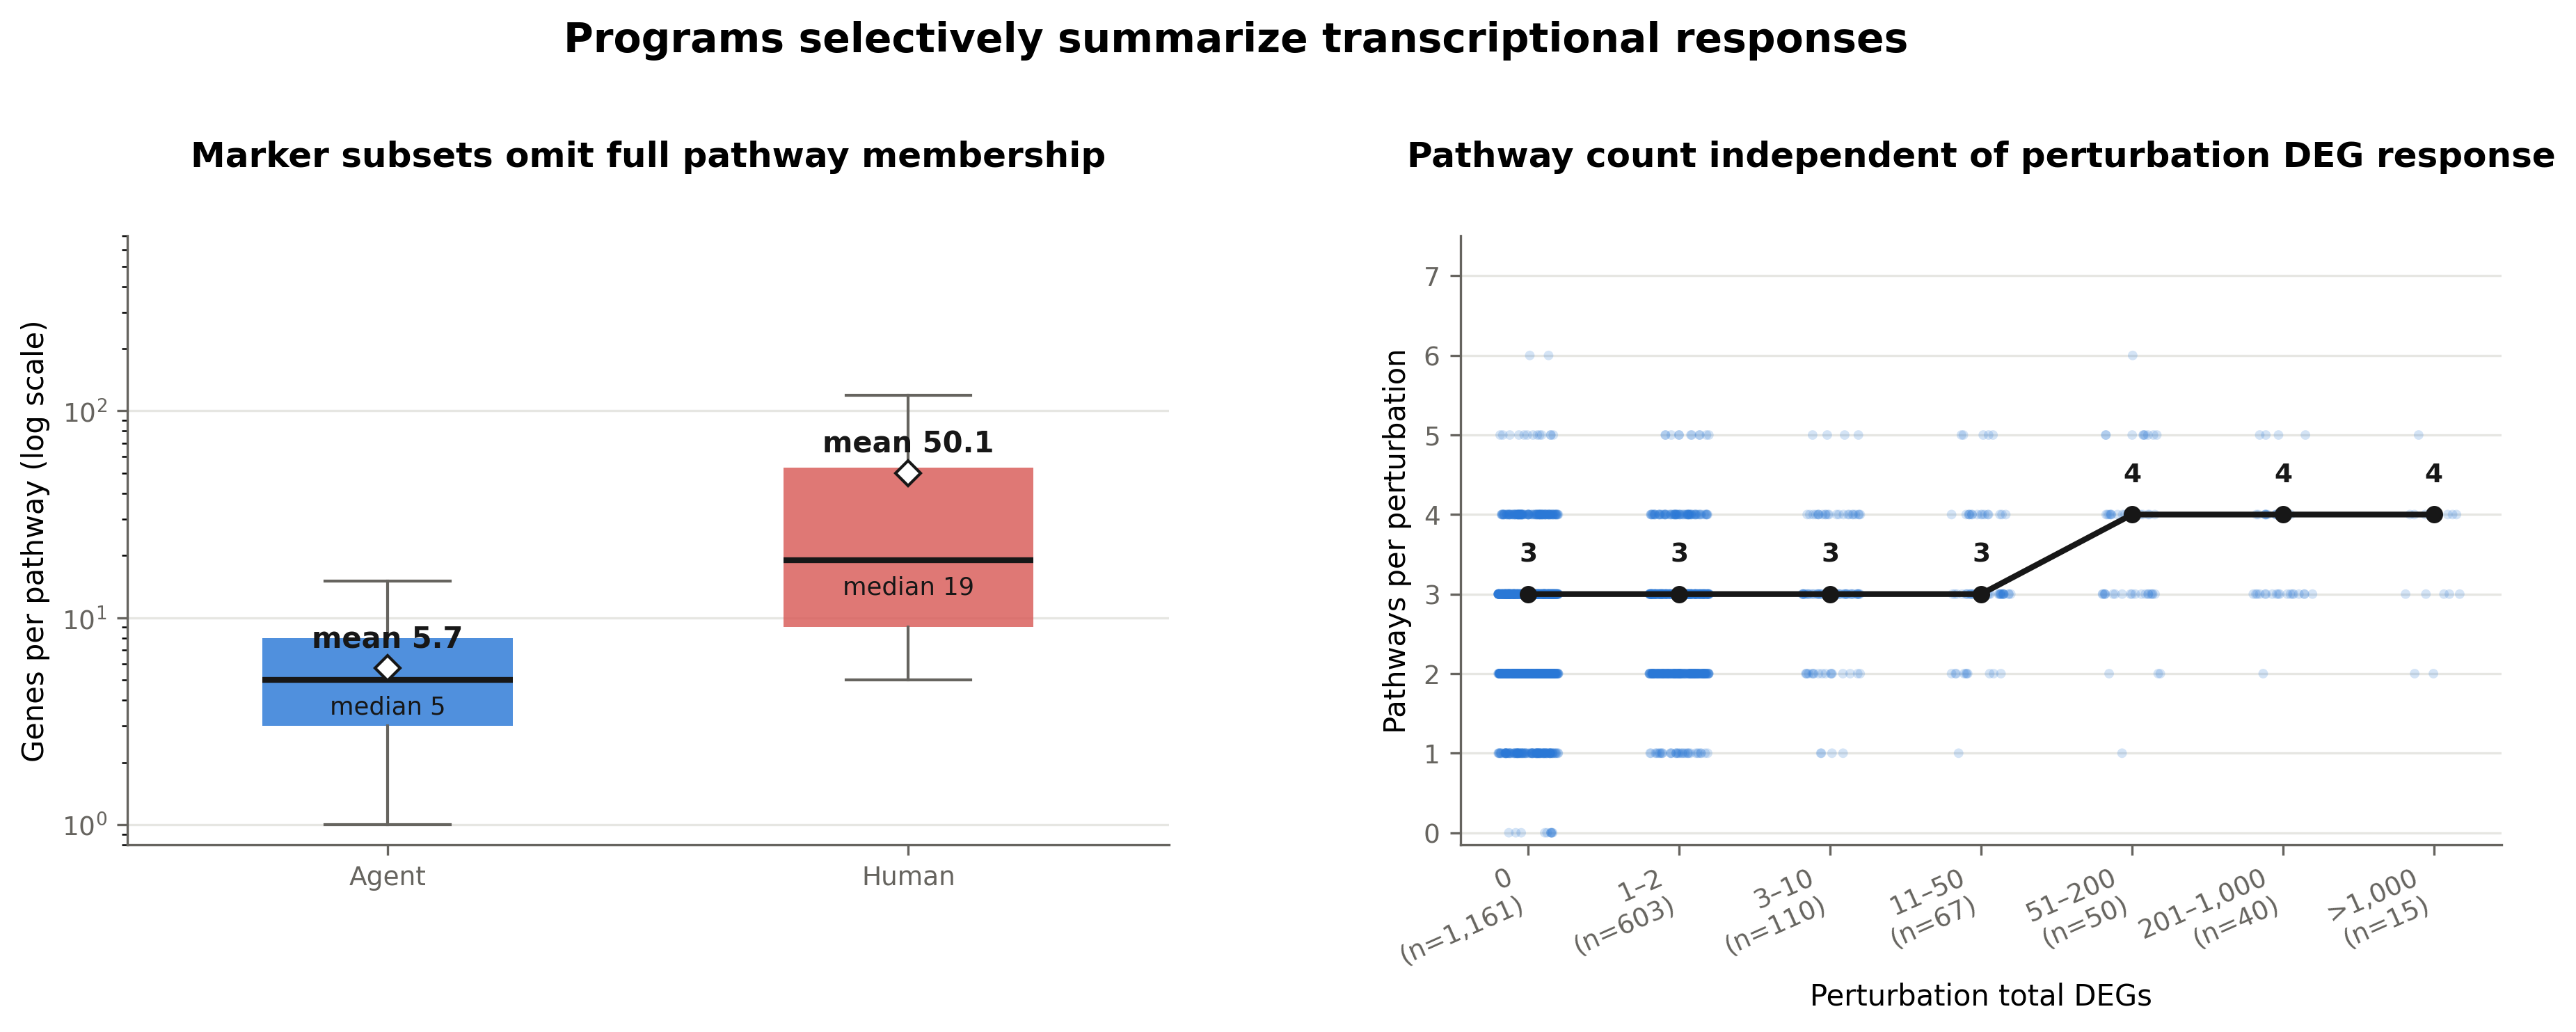

In [3]:
def plot_gene_set_sizes(ax, report_values, canonical_values):
    values = [report_values, canonical_values]
    box = ax.boxplot(
        values, positions=[1, 2], widths=0.48, patch_artist=True, showfliers=False, showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": INK, "markersize": 6},
        medianprops={"color": INK, "linewidth": 2},
        whiskerprops={"color": MUTED}, capprops={"color": MUTED},
    )
    for patch, color in zip(box["boxes"], [BLUE, RED]):
        patch.set_facecolor(color)
        patch.set_alpha(0.82)
        patch.set_edgecolor("none")

    means = [report_values.mean(), canonical_values.mean()]
    medians = [np.median(report_values), np.median(canonical_values)]
    for x, mean, median in zip([1, 2], means, medians):
        ax.text(x, mean * 1.18, f"mean {mean:.1f}", ha="center", va="bottom", fontsize=10, color=INK, fontweight="bold")
        ax.text(x, median / 1.18, f"median {median:.0f}", ha="center", va="top", fontsize=8.5, color=INK)

    style(ax, grid_axis="y")
    ax.set_yscale("log")
    ax.set_ylim(0.8, 700)
    ax.set_xticks([1, 2], ["Agent", "Human"])
    ax.set_ylabel("Genes per pathway (log scale)", fontsize=10)
    ax.set_title("Marker subsets omit full pathway membership", fontsize=12, fontweight="bold", pad=24)

def plot_program_count(ax, data):
    edges = [-1, 0, 2, 10, 50, 200, 1000, np.inf]
    labels = ["0", "1–2", "3–10", "11–50", "51–200", "201–1,000", ">1,000"]
    data = data.copy()
    data["burden_bin"] = pd.cut(data.n_unique_deg_genes, edges, labels=labels)
    groups = [data.loc[data.burden_bin == label, "n_programs"].to_numpy() for label in labels]

    rng = np.random.default_rng(14)
    for i, values in enumerate(groups, start=1):
        jitter = rng.uniform(-0.20, 0.20, size=len(values))
        ax.scatter(np.full(len(values), i) + jitter, values, s=11, alpha=0.20, color=BLUE, edgecolors="none", rasterized=True)

    medians = np.asarray([np.median(values) if len(values) else np.nan for values in groups])
    ax.plot(range(1, len(labels) + 1), medians, "-o", color=INK, linewidth=2, markersize=5, zorder=4)
    for i, (values, median) in enumerate(zip(groups, medians), start=1):
        if len(values):
            ax.text(i, median + 0.34, f"{median:.0f}", ha="center", va="bottom", fontsize=9, color=INK, fontweight="bold")

    style(ax, grid_axis="y")
    ax.set_xlim(0.55, len(labels) + 0.45)
    ax.set_ylim(-0.15, max(7.5, data.n_programs.max() + 0.8))
    tick_labels = [f"{label}\n(n={len(values):,})" for label, values in zip(labels, groups)]
    ax.set_xticks(range(1, len(labels) + 1), tick_labels, rotation=24, ha="right")
    ax.set_xlabel("Perturbation total DEGs", fontsize=10)
    ax.set_ylabel("Pathways per perturbation", fontsize=10)
    ax.set_title("Pathway count independent of perturbation DEG response", fontsize=12, fontweight="bold", pad=24)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.3), gridspec_kw={"wspace": 0.28})
plot_gene_set_sizes(axes[0], report_sizes, canonical_sizes)
plot_program_count(axes[1], report_summary)
fig.suptitle("Programs selectively summarize transcriptional responses", fontsize=14, fontweight="bold", y=0.975)
fig.subplots_adjust(left=0.075, right=0.985, top=0.78, bottom=0.23, wspace=0.28)
plt.show()

## Supplementary Figure 3C — expanded pathway direction

Direction agreement between listed marker subsets and complete pathway memberships.

In [4]:
matched = pd.read_csv(S3_ROOT / "c/expanded_pathway_direction_data.tsv", sep="\t")
same_sign = np.sign(matched.marker_nes) == np.sign(matched.canonical_nes)
directional = matched[matched.report_direction.isin(["down", "up"])].copy()
directional["aligned"] = np.where(
    directional.report_direction.eq("up"),
    directional.canonical_nes > 0,
    directional.canonical_nes < 0,
)
direction_counts = matched.report_direction.value_counts()
down = directional[directional.report_direction.eq("down")]
up = directional[directional.report_direction.eq("up")]

assert len(matched) == 625 and int(same_sign.sum()) == 601
assert len(down) == 121 and int(down.aligned.sum()) == 120
assert len(up) == 201 and int(up.aligned.sum()) == 201
assert len(directional) == 322 and int(directional.aligned.sum()) == 321

print(f"matched programs={len(matched):,}; directional programs={len(directional):,}")
print(f"NES-sign agreement={same_sign.sum():,}/{len(matched):,} ({same_sign.mean():.1%})")
print(f"DOWN agreement={down.aligned.sum():,}/{len(down):,} ({down.aligned.mean():.1%})")
print(f"UP agreement={up.aligned.sum():,}/{len(up):,} ({up.aligned.mean():.1%})")
print(f"overall direction agreement={directional.aligned.sum():,}/{len(directional):,} ({directional.aligned.mean():.1%})")
display(direction_counts.rename_axis("report_direction").to_frame("matched_programs"))

matched programs=625; directional programs=322
NES-sign agreement=601/625 (96.2%)
DOWN agreement=120/121 (99.2%)
UP agreement=201/201 (100.0%)
overall direction agreement=321/322 (99.7%)


,matched_programs
report_direction,
up,201
non-directional,182
down,121
mixed,121


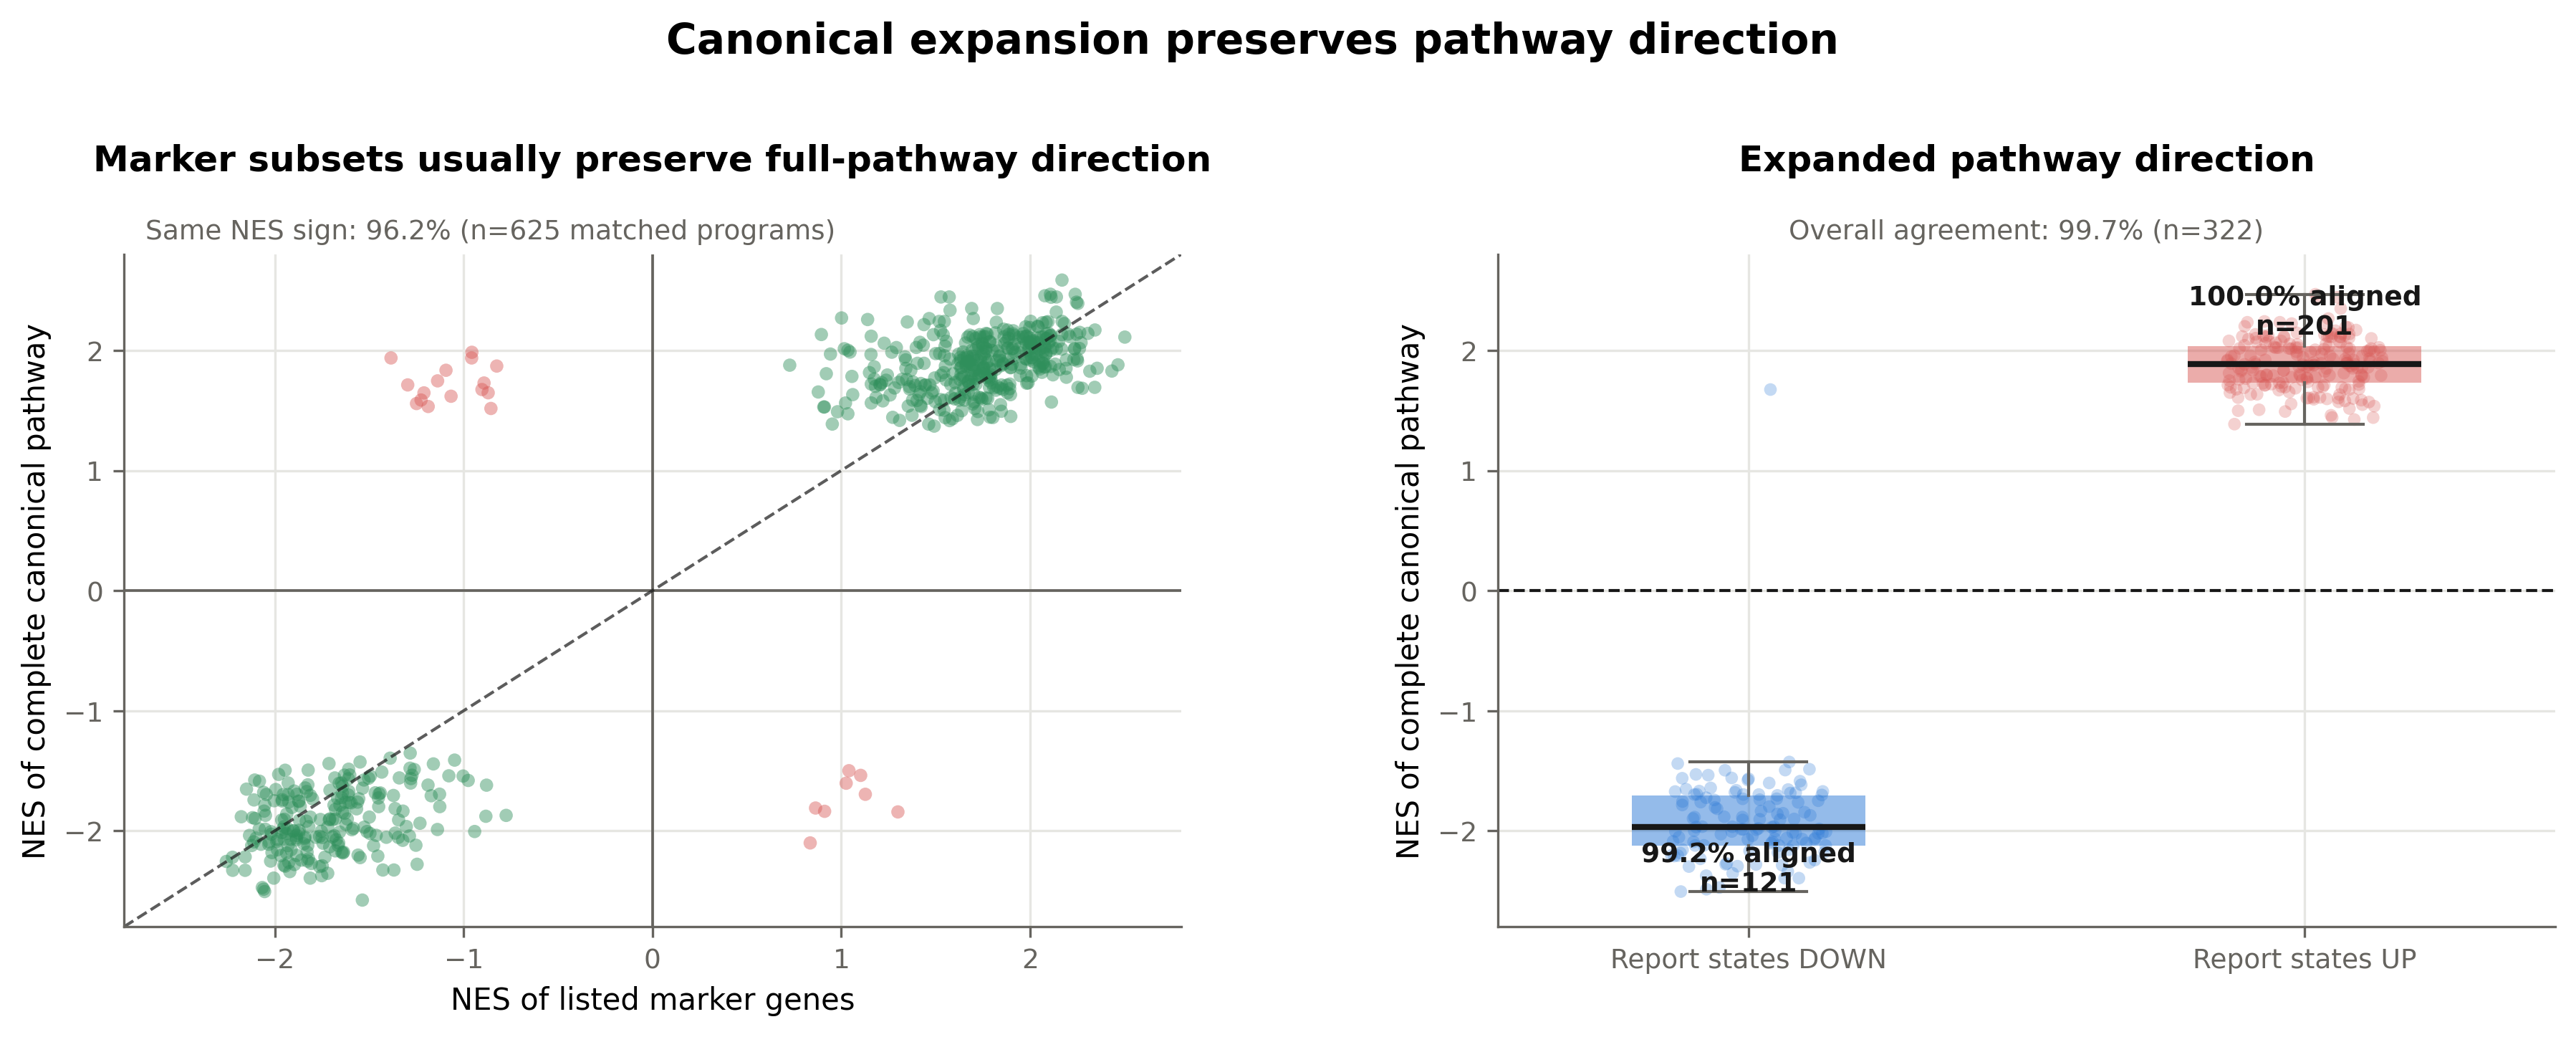

In [5]:
def plot_marker_vs_canonical(ax, data):
    aligned = np.sign(data.marker_nes) == np.sign(data.canonical_nes)
    colors = np.where(aligned, GREEN, RED)
    ax.scatter(data.marker_nes, data.canonical_nes, c=colors, s=20, alpha=0.45, edgecolors="none", rasterized=True)
    lim = max(2.8, np.nanmax(np.abs(data[["marker_nes", "canonical_nes"]].to_numpy())) * 1.05)
    ax.axhline(0, color=MUTED, linewidth=0.9)
    ax.axvline(0, color=MUTED, linewidth=0.9)
    ax.plot([-lim, lim], [-lim, lim], linestyle="--", color=INK, linewidth=1.0, alpha=0.7)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    style(ax)
    ax.set_xlabel("NES of listed marker genes", fontsize=10)
    ax.set_ylabel("NES of complete canonical pathway", fontsize=10)
    ax.set_title("Marker subsets usually preserve full-pathway direction", fontsize=12, fontweight="bold", pad=28)
    ax.text(0.02, 1.015, f"Same NES sign: {aligned.mean():.1%} (n={len(data):,} matched programs)", transform=ax.transAxes, color=MUTED, fontsize=9, va="bottom")

def plot_report_direction(ax, data):
    directional_data = data[data.report_direction.isin(["down", "up"])].copy()
    rng = np.random.default_rng(14)
    groups = []
    for position, direction, color in [(1, "down", BLUE), (2, "up", RED)]:
        values = directional_data.loc[directional_data.report_direction == direction, "canonical_nes"].to_numpy()
        groups.append(values)
        jitter = rng.uniform(-0.14, 0.14, size=len(values))
        ax.scatter(np.full(len(values), position) + jitter, values, s=18, alpha=0.28, color=color, edgecolors="none", rasterized=True)

    box = ax.boxplot(
        groups, positions=[1, 2], widths=0.42, patch_artist=True, showfliers=False,
        medianprops={"color": INK, "linewidth": 2},
        whiskerprops={"color": MUTED}, capprops={"color": MUTED},
    )
    for patch, color in zip(box["boxes"], [BLUE, RED]):
        patch.set_facecolor(color)
        patch.set_alpha(0.50)
        patch.set_edgecolor("none")

    ax.axhline(0, color=INK, linestyle="--", linewidth=1)
    for position, direction, values in zip([1, 2], ["down", "up"], groups):
        expected = (values < 0).mean() if direction == "down" else (values > 0).mean()
        y = -2.55 if direction == "down" else 2.55
        va = "bottom" if direction == "down" else "top"
        ax.text(position, y, f"{expected:.1%} aligned\nn={len(values):,}", ha="center", va=va, fontsize=9, color=INK, fontweight="bold")

    aligned = np.where(
        directional_data.report_direction.eq("up"),
        directional_data.canonical_nes > 0,
        directional_data.canonical_nes < 0,
    )
    style(ax)
    ax.set_xlim(0.55, 2.45)
    ax.set_ylim(-2.8, 2.8)
    ax.set_xticks([1, 2], ["Report states DOWN", "Report states UP"])
    ax.set_ylabel("NES of complete canonical pathway", fontsize=10)
    ax.set_title("Expanded pathway direction", fontsize=12, fontweight="bold", pad=28)
    ax.text(0.5, 1.015, f"Overall agreement: {aligned.mean():.1%} (n={len(directional_data):,})", transform=ax.transAxes, ha="center", color=MUTED, fontsize=9, va="bottom")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.3), gridspec_kw={"wspace": 0.30})
plot_marker_vs_canonical(axes[0], matched)
plot_report_direction(axes[1], matched)
fig.suptitle("Canonical expansion preserves pathway direction", fontsize=14, fontweight="bold", y=0.975)
fig.subplots_adjust(left=0.08, right=0.985, top=0.77, bottom=0.18, wspace=0.30)
plt.show()